### Data Analysis
- 원시(원본 그대로) 데이터를 분석하여 인사이트(가시성 증가 및 깊은 이해)로 변환하는 작업이다.
- 문제를 해결하기 위해 데이터를 사용해서 흐름 및 방향을 찾는 기술이다.
- 데이터 분석을 통해 비지니스 프로세스를 구성하고, 의사 결정을 개선하며, 비지니스 성장을 증진할 수 있다.

<img src="./images/architecture.png" width="900px" style="margin-left: 10px;">
** <sub>ETL은 Extract(추출), Transform(변환), Load(적재)를 의미한다. 여기 저기 흩어진 데이터를 하나로 모으기 위한 결합 과정이다.</sub>

### 기초 통계 (Basic statistics)
📌 통계는 아직 발생하지 않은 일을 예측하기 위해 사용한다.
- 통계학을 공부하는 데 있어 필요한 기본 개념이고,  
  수량적인 비교를 기초로 많은 사실을 관찰하고 처리하는 방법을 연구하는 학문이다.
- 불균형 데이터를 대상으로 규칙성과 불규칙성을 발견한 뒤 실생활에 적용할 수 있다.  

<img src="./images/statistics01.png" style="margin-top: 20px">

#### 변량(Variable)
- 자료의 수치를 변량이라고 하며, 이는 데이터의 값을 의미한다.

In [1]:
# %pip install numpy pandas

  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.6 MB 1.9 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.6 MB 2.0 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/12.6 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.6/12.6 MB 1.7 MB/s eta 0:00:07
   ----- ---------------------------------- 1.8/12.6 MB 1.5 MB/s eta 0:00:08
   ------- -------------------------------- 2.4/12.6 MB 1.6 MB/s eta 0:00:07
   --------- ------------------------------ 3.1/12.6 MB 1.8 MB/s eta 0:00:06
   --------- ------------------------------ 3.1/12.6 MB 1.8 MB/s eta 0:00:06
   ----------- ---------------------------- 3.7/12.6 MB 1.8 MB/s eta 0:00:05
   ------------- -------------------------- 4.2/12.6 MB 1.9 MB/s eta 0:00:05
   -------------- -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras 3.13.2 requires namex, which is not installed.
lightgbm 4.6.0 requires scipy, which is not installed.
tensorflow 2.21.0 requires flatbuffers>=25.9.23, which is not installed.
tensorflow 2.21.0 requires grpcio<2.0,>=1.24.3, which is not installed.
tensorflow 2.21.0 requires libclang>=13.0.0, which is not installed.
tensorflow 2.21.0 requires opt_einsum>=2.3.2, which is not installed.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, which is not installed.
tensorflow 2.21.0 requires termcolor>=1.1.0, which is not installed.
tensorflow 2.21.0 requires wrapt>=1.11.0, which is not installed.


In [4]:
import numpy as np
import pandas as pd

df = pd.DataFrame(np.random.randint(151, 190, size=(10, 10)), \
                  columns="서울,경기,인천,광주,대구,부산,전주,강릉,울산,수원".split(","))
display(df)

,서울,경기,인천,광주,대구,부산,전주,강릉,울산,수원
0,162,156,188,155,188,152,181,160,161,179
1,178,151,189,175,153,160,188,151,152,162
2,179,155,168,186,183,158,184,170,161,162
3,157,184,184,179,188,161,162,160,184,153
4,155,187,186,184,184,165,156,160,156,175
5,178,159,155,189,157,176,166,184,180,160
6,177,183,176,180,188,178,164,155,180,157
7,174,166,154,166,162,169,165,175,164,185
8,170,160,163,151,176,185,158,170,182,159
9,159,160,178,183,177,184,167,153,169,161


#### 계급 (Class)
- 변량을 일정 간격으로 나눈 구간을 의미한다.
- 변량의 최소값과 최대값을 잘 고려해서 계급을 정해야한다.
- 예를 들어, 계급이 (150, 160]일 경우, 151 ~ 160이 계급에 속한다. 즉 소괄호는 구간 미포함, 대괄호는 구간 포함이다.

In [6]:
df_seoul = df['서울']
df_class = pd.cut(df_seoul, bins=[150, 160, 170, 180, 190])
df_seoul_class = pd.DataFrame({"서울": df_seoul, "계급": df_class})

display(df_seoul_class)

,서울,계급
0,162,"(160, 170]"
1,178,"(170, 180]"
2,179,"(170, 180]"
3,157,"(150, 160]"
4,155,"(150, 160]"
5,178,"(170, 180]"
6,177,"(170, 180]"
7,174,"(170, 180]"
8,170,"(160, 170]"
9,159,"(150, 160]"


#### 도수(Frequency)
- 각 계급에 속하는 변량의 개수를 의미한다.

In [8]:
# observed: 결과가 0개일 때 표시 여부
# False: 표시, True: 미표시
df_seoul_class.groupby('계급', observed=False).count()

,서울
계급,
"(150, 160]",3
"(160, 170]",2
"(170, 180]",5
"(180, 190]",0


#### 상대 도수
- 각 계급에 속하는 변량의 비율을 의미한다.

In [11]:
df_seoul_class.groupby('계급', observed=False).count().apply(lambda x: x / len(df_seoul))

,서울
계급,
"(150, 160]",0.3
"(160, 170]",0.2
"(170, 180]",0.5
"(180, 190]",0.0


#### 도수분포표(Frequency table)
- 주어진 자료를 계급별로 나눈 뒤 각 계급에 속하는 도수 및 상대 도수를 조사한 표이다.
- 구간별 분포를 한 번에 알아보기 좋지만 계급별 각 변량의 정확한 값이 생략되어 있다.

In [16]:
freq = df_seoul_class.groupby('계급', observed=False).count()['서울']
r_freq = df_seoul_class.groupby('계급', observed=False).count().apply(lambda x: x / len(df_seoul))['서울']

freq_df = pd.DataFrame({'도수': freq, '상대도수': r_freq})
display(freq_df)

,도수,상대도수
계급,,
"(150, 160]",3,0.3
"(160, 170]",2,0.2
"(170, 180]",5,0.5
"(180, 190]",0,0.0


In [17]:
freq_df.reset_index(drop=False, inplace=True)
display(freq_df)

,계급,도수,상대도수
0,"(150, 160]",3,0.3
1,"(160, 170]",2,0.2
2,"(170, 180]",5,0.5
3,"(180, 190]",0,0.0


#### 히스토그램(Histogram)
- 도수분포표를 시각화한 그래프이다.

In [18]:
# %pip install matplotlib

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.1 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.3 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.1 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8

In [19]:
df_seoul_class['서울']

0    162
1    178
2    179
3    157
4    155
5    178
6    177
7    174
8    170
9    159
Name: 서울, dtype: int32

<Axes: >

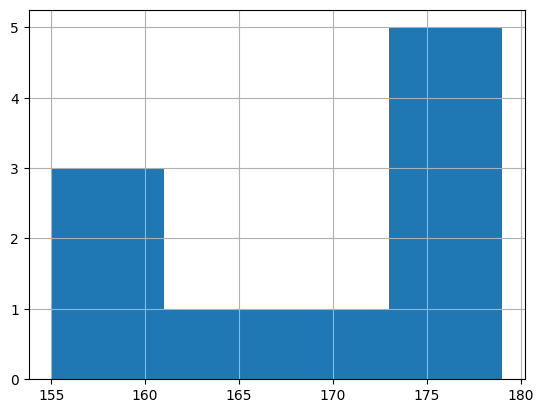

In [21]:
import matplotlib.pyplot as plt

df_seoul_class['서울'].hist(bins=4)

#### 산술 평균 (Mean)
- 변량의 합을 변량의 수로 나눈 값을 의미한다.

<img src="./images/mean.png" style="margin-left: 20px;">

In [22]:
df.mean(axis=0).to_frame(name="평균 키")

,평균 키
서울,168.9
경기,166.1
인천,174.1
광주,174.8
대구,175.6
부산,168.8
전주,169.1
강릉,163.8
울산,168.9
수원,165.3


#### 편차(Deviation)
- 변량에서 평균을 뺀 값이다.
- 각 변량의 편차를 구한 뒤 모두 합하면 0이 되기 때문에 편차의 평균은 구할 수 없다.

In [26]:
g_df = df['경기'].to_frame()
g_df['편차'] = g_df['경기'].apply(lambda x: x - g_df.mean())

display(g_df)
print(round(g_df['편차'].sum()))

,경기,편차
0,156,-10.1
1,151,-15.1
2,155,-11.1
3,184,17.9
4,187,20.9
5,159,-7.1
6,183,16.9
7,166,-0.1
8,160,-6.1
9,160,-6.1


0


#### 분산 (Variance)
- 변량이 평균으로부터 떨어져있는 정도를 보기 위한 통계량이다.
- 편차에 제곱하여 그 합을 구한 뒤 산술 평균을 낸다.

<img src="./images/variance.png" style="margin-left: 10px">

In [30]:
g_df['편차의 제곱'] = g_df['편차'].apply(lambda x: x**2)
display(g_df)

variance = g_df['편차의 제곱'].mean()
print(f'분산 {round(variance, 2)}')

,경기,편차,편차의 제곱
0,156,-10.1,102.01
1,151,-15.1,228.01
2,155,-11.1,123.21
3,184,17.9,320.41
4,187,20.9,436.81
5,159,-7.1,50.41
6,183,16.9,285.61
7,166,-0.1,0.01
8,160,-6.1,37.21
9,160,-6.1,37.21


분산 162.09


#### 표준편차 (Standard deviation)
- 분산의 제곱근이며, 관측된 변량의 흩어진 정도를 하나의 수치로 나타내는 통계량이다.
- 표준편차가 작을 수록 평균 값에서 변량들의 거리가 가깝다고 판단한다.

<img src="./images/standard_deviation.png" style="margin-left: 15px">

In [31]:
import math

std = math.sqrt(variance)
print(f'표준편차: {round(std, 2)}')

표준편차: 12.73


#### 확률변수 (Random variable)
- 머신러닝, 딥러닝 등 확률을 다루는 분야에 있어서 필수적인 개념이다.
- 확률(probability)이 있다는 뜻은 사건(event)이 있다는 뜻이며,  
  시행(trial)을 해야 시행의 결과인 사건(event)이 나타난다.
- 시행(trial)을 해서 어떤 사건(event)이 나타났는지에 따라 값이 정해지는 변수이다.
- 알파벳 대문자로 표현하며, X, Y, Z 또는 X<sub>1</sub>, X<sub>2</sub>, X<sub>3</sub>과 같이 표현한다.
- 확률변수는 집합이며, 원소를 확률변수값(Value of random variable)이라고 표현한다.  
  확률변수에서 사용한 알파벳의 소문자를 사용한다.
- Y = { y<sub>1</sub>, y<sub>2</sub>, y<sub>3</sub> }, 이 때 Y는 확률변수이고 원소인 y<sub>1</sub> ~ y<sub>3</sub>은 확률변수값이다.

<img src="./images/random_variable.jpg" width="700px" style="margin-left: 15px">

#### 범주형 확률변수 (Categorical random variable)
- 범주형 확률변수값은 수치가 아닌 기호나 언어, 숫자등으로 표현하고, 기호나 언어는 순서를 가질 수도 있다.
- 유한집합으로 표현한다. 유한집합은 원소의 수가 유한한 집합을 의미한다.
- {앞면, 뒷면}, {동의, 비동의}, {선택, 미선택}, {봄, 여름, 가을, 겨울}

#### 이산형 확률변수 (Discrete random variable)
- 이산형 확률변수값은 수치로 표현하고 셀 수 있는 값이다. 이를 더 넓은 범위로,  
  양적 확률변수 또는 수치형 확률변수라고도 부른다.
- 유한집합 또는 셀 수 있는 무한집합으로 표현한다. 무한집합은 원소의 수가 무한한 집합을 의미한다.
- {0, 1, 2, 3}, {10, 20, 30}, {1, 2, 3, ...}, {100, 1000, 10000}

#### 연속형 확률변수 (Continuous random variable)
- 연속형 확률변수는 구간을 나타내는 수치로 표현한다. 이를 더 넓은 범위로,  
  양적 확률변수 또는 수치형 확률변수라고도 부른다.
- 셀 수 없는 무한집합으로 표현한다.
- 128.56 < X < 268.56

#### 확률분포 (Probability distribution)
- 사건에 대한 확률변수에서 정의된 모든 확률값의 분포이며, 서로 다른 모든 결과의 출현 확률을 제공한다.
  
> <strong>1) 동전 던지기 (시행)</strong>  
> <strong>2) { 0, 1 } (확률변수와 확률변수값)</strong>  
> <strong>3) 완벽한 형태의 동전일 경우 확률 분포</strong>  
>
> <img src="./images/probability_distribution01.png">  

  
> <strong>1) 1 ~ 12까지 새겨진 주사위 던지기 (시행)</strong>  
> <strong>2) { 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 } (확률변수와 확률변수값)</strong>  
> <strong>3) 완벽한 형태의 주사위일 경우 확률 분포</strong>  
>
> <img src="./images/probability_distribution02.png">

#### 확률분포표 (Probability distribution table)
- 확률변수의 모든 값(원소)에 대해 확률을 표로 표시한 것이다.
- 범주형 또는 이산형 확률변수의 확률분포를 표현하기에 적합한 방식이다.

In [37]:
import numpy as np
import pandas as pd

h_dist_df = pd.DataFrame(np.arange(0, 100) % 4 + 1, columns=['경주마 번호'])
h_dist_group_df = h_dist_df.groupby('경주마 번호')['경주마 번호'].count().reset_index(name='1등 횟수')
h_dist_group_df['1등할 확률'] = h_dist_group_df['1등 횟수'] / len(h_dist_df)

display(h_dist_group_df)

,경주마 번호,1등 횟수,1등할 확률
0,1,25,0.25
1,2,25,0.25
2,3,25,0.25
3,4,25,0.25


#### 확률분포함수 (Probability distribution function)
- 확률변수의 분포를 나타내는 함수로서, 확률변수의 확률변수값이 나올 확률을 나타내는 함수이다.
- 확률질량함수, 확률밀도함수 등의 함수가 있다.

(array([0.25, 0.25, 0.25, 0.25]),
 array([1., 2., 3., 4., 5.]),
 <BarContainer object of 4 artists>)

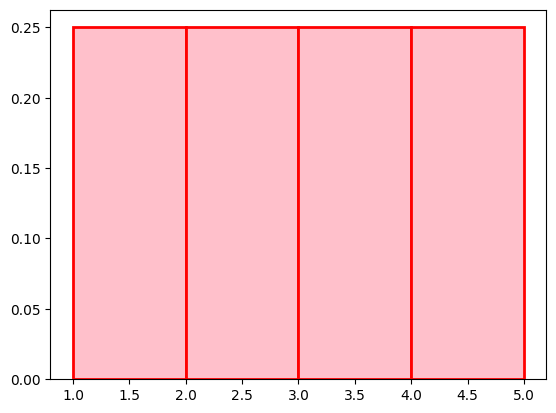

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(h_dist_df['경주마 번호'], bins=range(1, 6), \
        density=True, color='pink', edgecolor='red', linewidth=2)

#### 확률질량 함수 (Probability mass function, pmf)
- 확률변수 X의 분포를 나타내는 함수로서, x<sub>i</sub>가 나올 확률이다.
- 확률변수의 값을 매개변수로 전달받고, 해당 값이 나타날 확률을 구해서 리턴하는 함수이다.
- 범주형 확률변수와 이산형 확률변수에서 사용된다.
- 확률변수에서 각 값에 대한 확률을 나타내는 것이 마치 각 값이 "질량"을 가지고 있는 것처럼 보이기 때문에 확률질량 함수로 불린다.

> 확률질량 함수 f는 확률변수 X가 x를 변수값으로 가질 때의 확률이다.  
> <img src="./images/pmf01.png" style="margin-top: 10px">  
> <img src="./images/pmf02.png">  
> <img src="./images/pmf03.png">  

In [39]:
import numpy as np
import pandas as pd

h_df = pd.DataFrame(np.random.randint(1, 5, size=(100, 1)), columns=['경주마 번호'])
h_group_df = h_df.groupby('경주마 번호')['경주마 번호'].count().reset_index(name='1등 횟수')

h_group_df['1등할 확률'] = h_group_df['1등 횟수'] / len(h_df)

display(h_group_df)

,경주마 번호,1등 횟수,1등할 확률
0,1,15,0.15
1,2,31,0.31
2,3,28,0.28
3,4,26,0.26


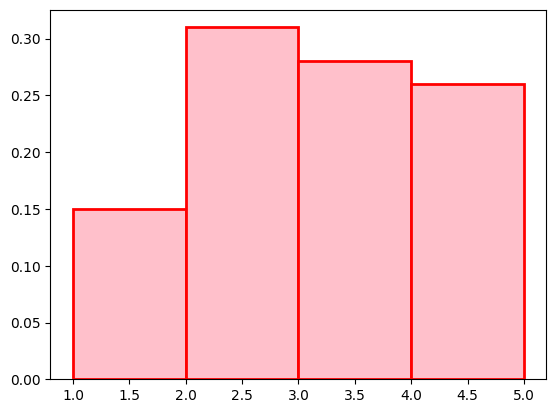

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(h_df['경주마 번호'], range(1, 6), \
        density=True, color='pink', edgecolor='red', linewidth=2)

plt.show()

#### 무한대 (Infinity)
- 끝없이 커지는 상태를 의미하고 기호로 ∞를 사용한다.

#### 무한소 0 (Infinitesimal)
- 거의 없다는 의미이고, 0에 매우 근접하지만 0이 아닌 상태를 의미한다.

#### 미분 (Differential)
- 기울기는 독립변수가 종속변수에 미치는 영향력의 크기를 의미한다.
- 변경 전의 독립변수 x<sub>1</sub>이라는 점과 변경 후의 x<sub>2</sub>라는 점을 지나는 직선의 기울기가 바로 변화에 대한 속도이다.
- 즉, 직선의 기울기가 4로 구해졌다면,  
  종속변수가 독립변수의 변화에 4배 속도로 변화된 것이다.
- 이 때, 두 점 사이가 무한히 가까워지면,  
  결국 거의 한 점과 같은 점에 대한 접선의 기울기가 되고 이는 순간적인 변화량이다.
- 미분을 통해서 독립변수가 미세하게 변화할 때 순간적으로 종속변수가 얼마나 빠르게 변화하는 지를 알 수 있다.

#### 적분 (Integral)
- 선분 = 높이(길이), 면적 = 가로 X 높이
- 면적을 구할 때 여러 사각형으로 나눈 뒤 합하여도 전체 면적이 나온다.
- 가로가 무한소 0인 사각형 즉, 선분과 거의 비슷한 사각형을 쌓은 뒤, 각 면적을 모두 합하는 것이 적분이다.

#### 확률밀도 함수 (Probability density function, pdf)
- 확률변수 X의 분포를 나타내는 함수로서, 특정 구간에 속할 확률이고 이는 특정 구간을 적분한 값이다.
- 확률변수값의 범위(구간)를 매개변수로 전달받고, 범위의 넓이를 구해서 리턴하는 함수이다.
- 연속형 확률변수에서 사용된다.
- 전체에 대한 확률이 아닌 구간에 포함될 확률을 나타내기 때문에 구간에 따른 밀도를 구하는 것이고,  
  이를 통해 확률밀도 함수라 불린다.

> 확률밀도 함수 f는 특정 구간에 포함될 확률을 나타낸다.  
> <img src="./images/pdf01.png" style="margin-top: 10px">  
> <img src="./images/pdf02.png">  
> <img src="./images/pdf03.png">  
> <img src="./images/pdf04.png">

> <img src="./images/normal_distribution03.png" width="230px" style="margin-left: 20px">

In [1]:
%pip install scipy

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# 구적법(求積法), 넓이를 구하는 방법
# Quadrature(쿼드라쳐): 정사각형의 라틴어, 곡선의 넓이와 똑같은 넓이를 가진 정사각형
from scipy.integrate import quad

def pdf(x):
    mu = 0
    sigma = 1
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-((x - mu) / sigma) ** 2 / 2)

def calculate_probability_in_range(a, b):
    probability, _ = quad(pdf, a, b)
    return probability

a = -1
b = 2

probability = calculate_probability_in_range(a, b)
print(f'구간 [{a}, {b}]에서의 확률: {probability}')

구간 [-1, 2]에서의 확률: 0.8185946141203638


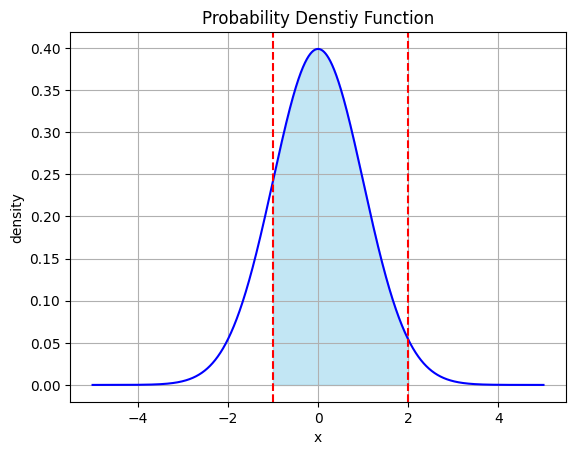

구간 [-1, 2]에서의 확률: 0.8185946141203638


In [4]:
x_values = np.linspace(-5, 5, 10000)
y_values = pdf(x_values)

plt.plot(x_values, y_values, label='pdf', color='blue')
plt.fill_between(x_values, y_values, \
                where=(x_values >= a) & (x_values <= b), \
                color='skyblue', alpha=0.5, label='area')
plt.axvline(x=a, linestyle='--', color='red', label='start')
plt.axvline(x=b, linestyle='--', color='red', label='end')
plt.xlabel('x')
plt.ylabel('density')
plt.title('Probability Denstiy Function')
plt.grid(True)
plt.show()
print(f'구간 [{a}, {b}]에서의 확률: {probability}')

#### 정규분포 (Normal distribution)
- 모든 독립적인 확률변수들의 평균은 어떠한 분포에 가까워지는데, 이 분포를 정규분포라고 한다.
- 즉, 비정규분포의 대부분은 극한상태에 있어서 정규분포에 가까워진다.

<div>
<img src="./images/normal_distribution01.png" width="700px"> <img src="./images/normal_distribution02.png" width="700px">  
</div>  

- 평균 μ(mu)와 표준편차 σ(sigma)에 대해 아래의 확률밀도함수를 가지는 분포를 의미한다.  
- 평균을 중심으로 발생하는 무작위 오차를 시각화 한 것이 정규 분포이다.
<img src="./images/normal_distribution04.png" width="700px" style="margin-left: 10px">


#### 표준 정규분포 (Standard normal distribution)
- 정규분포는 평균과 표준편차에 따라서 모양이 달라진다.

<img src="./images/standard_normal_distribution01.png" width="600px" style="margin-left: -20px">  

- 정규분포를 따르는 분포는 많지만 각 평균과 표준편차가 달라서 일반화할 수 없다.
- N(μ, σ) = N(0, 1)로 만든다면 모두 같은 특성을 가지는 동일한 확률분포로 바꿔서 일반화할 수 있다.
- 따라서 일반 정규분포를 표준 정규분포로 바꾼 뒤 표준 정규분포의 특정 구간의 넓이를 이용해서 원래 분포의 확률을 구할 수 있다.

#### 표준화 (Standardization)
- 다양한 형태의 정규분포를 표준 정규분포로 변환하는 방법이다.
- 표준 정규분포에 대한 값(넓이)를 이용해 원래 분포의 확률을 구할 수 있다.  

<img src="./images/standardization01.png" style="margin-left: 20px">  

<img src="./images/standardization02.png" style="margin-left: 20px">

#### 모집단과 모수 (Population and population parameter)
- 모집단이란, 정보를 얻고자 하는 대상의 전체 집합을 의미한다.
- 모수란, 모집단의 수치적 요약값을 의미한다. 평균 또는 표준편차와 같은 모집단의 통계값을 모수라고 한다.